In [1]:
# ============================================================
# PARTIE III — RNN, LSTM, GRU, SEQ2SEQ
# Dataset : IMDb (critiques de films)
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re, random

# Fix pour le problème de tokenizer
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
device = torch.device("cpu")
print("Imports OK | Device:", device)

# ── CHARGEMENT IMDB ──────────────────────────────────────────
from datasets import load_dataset
print("Chargement du dataset IMDb...")
dataset = load_dataset("imdb")

# On prend un sous-ensemble pour aller plus vite
train_data = dataset['train'].shuffle(seed=42).select(range(2000))
test_data  = dataset['test'].shuffle(seed=42).select(range(500))

train_texts  = [d['text'] for d in train_data]
train_labels = [d['label'] for d in train_data]
test_texts   = [d['text'] for d in test_data]
test_labels  = [d['label'] for d in test_data]

print(f"Train : {len(train_texts)} critiques")
print(f"Test  : {len(test_texts)} critiques")
print(f"Exemple positif : {train_texts[0][:100]}...")
print(f"Label : {'Positif' if train_labels[0]==1 else 'Negatif'}")

# Distribution des classes
pos_train = sum(train_labels)
neg_train = len(train_labels) - pos_train
print(f"\nDistribution Train : {pos_train} positifs / {neg_train} negatifs")

# ── PREPROCESSING ─────────────────────────────────────────────
def nettoyer(texte):
    texte = re.sub(r'<.*?>', ' ', texte)      # enleve les balises HTML
    texte = re.sub(r'[^a-zA-Z ]', ' ', texte) # garde seulement les lettres
    texte = texte.lower().strip()
    return texte.split()

print("\nTokenisation en cours...")
train_tokens = [nettoyer(t) for t in train_texts]
test_tokens  = [nettoyer(t) for t in test_texts]

# Vocabulaire
all_tokens = []
for tokens in train_tokens:
    all_tokens.extend(tokens)

vocab_counter = Counter(all_tokens)
# Garde les 10000 mots les plus fréquents
TOP_K = 10000
mot2idx = {'<PAD>': 0, '<UNK>': 1}
for mot, _ in vocab_counter.most_common(TOP_K):
    mot2idx[mot] = len(mot2idx)

print(f"Taille vocabulaire : {len(mot2idx)} mots")

# Encodage avec padding/troncature
MAX_LEN = 200

def encoder(tokens, max_len=MAX_LEN):
    ids = [mot2idx.get(t, 1) for t in tokens]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids[:max_len]

X_train = torch.LongTensor([encoder(t) for t in train_tokens])
X_test  = torch.LongTensor([encoder(t) for t in test_tokens])
y_train = torch.LongTensor(train_labels)
y_test  = torch.LongTensor(test_labels)

print(f"Forme X_train : {X_train.shape}")
print(f"Forme X_test  : {X_test.shape}")

# DataLoaders
train_ds     = TensorDataset(X_train, y_train)
test_ds      = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)
print("DataLoaders crees !")

# ── MODELES RNN / LSTM / GRU ──────────────────────────────────
VOCAB_SIZE = len(mot2idx)
EMBED_DIM  = 64
HIDDEN_DIM = 128
OUTPUT_DIM = 2
N_LAYERS   = 2

class RNN_Simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.rnn       = nn.RNN(EMBED_DIM, HIDDEN_DIM, num_layers=N_LAYERS,
                                batch_first=True, dropout=0.3)
        self.fc        = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop      = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, h = self.rnn(e)
        return self.fc(self.drop(h[-1]))

class LSTM_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.lstm      = nn.LSTM(EMBED_DIM, HIDDEN_DIM, num_layers=N_LAYERS,
                                 batch_first=True, dropout=0.3)
        self.fc        = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop      = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, (hn, cn) = self.lstm(e)
        return self.fc(self.drop(hn[-1]))

class GRU_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.gru       = nn.GRU(EMBED_DIM, HIDDEN_DIM, num_layers=N_LAYERS,
                                batch_first=True, dropout=0.3)
        self.fc        = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop      = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, h = self.gru(e)
        return self.fc(self.drop(h[-1]))

rnn_model  = RNN_Simple().to(device)
lstm_model = LSTM_Model().to(device)
gru_model  = GRU_Model().to(device)
print(f"\nRNN  params : {sum(p.numel() for p in rnn_model.parameters()):,}")
print(f"LSTM params : {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"GRU  params : {sum(p.numel() for p in gru_model.parameters()):,}")

# ── ENTRAINEMENT ──────────────────────────────────────────────
def train_rnn(model, train_loader, test_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history   = {'train_loss':[], 'test_loss':[], 'train_acc':[], 'test_acc':[]}

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
            correct    += (out.argmax(1)==yb).sum().item()
            total      += yb.size(0)
        train_loss /= len(train_loader)
        train_acc   = correct / total

        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out    = model(Xb)
                loss   = criterion(out, yb)
                test_loss += loss.item()
                correct   += (out.argmax(1)==yb).sum().item()
                total     += yb.size(0)
        test_loss /= len(test_loader)
        test_acc   = correct / total

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f"Epoch[{epoch+1}/{epochs}] "
              f"TrainLoss:{train_loss:.4f} TrainAcc:{train_acc:.4f} "
              f"TestLoss:{test_loss:.4f} TestAcc:{test_acc:.4f}")
    return history

print("\n--- Entrainement RNN Simple ---")
history_rnn  = train_rnn(rnn_model,  train_loader, test_loader, epochs=5)
print("\n--- Entrainement LSTM ---")
history_lstm = train_rnn(lstm_model, train_loader, test_loader, epochs=5)
print("\n--- Entrainement GRU ---")
history_gru  = train_rnn(gru_model,  train_loader, test_loader, epochs=5)

# ── COMPARAISON ───────────────────────────────────────────────
print("\n" + "="*55)
print("📊 COMPARAISON RNN / LSTM / GRU SUR IMDB")
print("="*55)
print(f"RNN  - Test Acc : {history_rnn['test_acc'][-1]:.4f} ({history_rnn['test_acc'][-1]*100:.2f}%)")
print(f"LSTM - Test Acc : {history_lstm['test_acc'][-1]:.4f} ({history_lstm['test_acc'][-1]*100:.2f}%)")
print(f"GRU  - Test Acc : {history_gru['test_acc'][-1]:.4f} ({history_gru['test_acc'][-1]*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_rnn['test_loss'],  label='RNN',  color='red')
axes[0].plot(history_lstm['test_loss'], label='LSTM', color='blue')
axes[0].plot(history_gru['test_loss'],  label='GRU',  color='green')
axes[0].set_title('Test Loss : RNN vs LSTM vs GRU (IMDb)')
axes[0].set_xlabel('Epoque'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_rnn['test_acc'],  label='RNN',  color='red')
axes[1].plot(history_lstm['test_acc'], label='LSTM', color='blue')
axes[1].plot(history_gru['test_acc'],  label='GRU',  color='green')
axes[1].set_title('Test Accuracy : RNN vs LSTM vs GRU (IMDb)')
axes[1].set_xlabel('Epoque'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig('comparaison_rnn_lstm_gru.png', dpi=150)
plt.show()

# ── SEQ2SEQ ───────────────────────────────────────────────────
SOS_token, EOS_token, PAD_token = 0, 1, 2

paires = [
    ("je suis heureux", "i am happy"),
    ("tu es gentil", "you are kind"),
    ("il fait beau", "the weather is nice"),
    ("je mange une pomme", "i eat an apple"),
    ("tu parles bien", "you speak well"),
    ("il court vite", "he runs fast"),
    ("nous aimons la musique", "we love music"),
    ("vous etes bons", "you are good"),
    ("ils jouent ensemble", "they play together"),
    ("je lis un livre", "i read a book"),
    ("tu regardes la television", "you watch television"),
    ("il travaille beaucoup", "he works a lot"),
]

def build_vocab_seq(phrases):
    v = {'<SOS>':0, '<EOS>':1, '<PAD>':2}
    for phrase in phrases:
        for mot in phrase.lower().split():
            if mot not in v: v[mot] = len(v)
    return v

sources_seq = [p[0] for p in paires]
cibles_seq  = [p[1] for p in paires]
vocab_src   = build_vocab_seq(sources_seq)
vocab_tgt   = build_vocab_seq(cibles_seq)
idx2tgt     = {v:k for k,v in vocab_tgt.items()}
print(f"\nVocab source Seq2Seq : {len(vocab_src)} mots")
print(f"Vocab cible  Seq2Seq : {len(vocab_tgt)} mots")

def encoder_seq(phrase, v, max_len=8):
    tokens = phrase.lower().split()
    ids    = [v.get(t, 2) for t in tokens] + [EOS_token]
    if len(ids) < max_len: ids += [PAD_token]*(max_len-len(ids))
    return ids[:max_len]

X_seq = torch.LongTensor([encoder_seq(s, vocab_src) for s in sources_seq])
y_seq = torch.LongTensor([encoder_seq(t, vocab_tgt) for t in cibles_seq])

class Encodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=2)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
    def forward(self, x):
        return self.gru(self.embedding(x))

class Decodeur(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=2)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc        = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden):
        out, hidden = self.gru(self.embedding(x.unsqueeze(1)), hidden)
        return self.fc(out.squeeze(1)), hidden

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.encodeur = enc
        self.decodeur = dec
    def forward(self, src, tgt, teacher_forcing=0.5):
        _, hidden   = self.encodeur(src)
        input_token = tgt[:, 0]
        outputs     = torch.zeros(src.shape[0], tgt.shape[1],
                                  self.decodeur.fc.out_features).to(device)
        for t in range(1, tgt.shape[1]):
            pred, hidden    = self.decodeur(input_token, hidden)
            outputs[:, t]   = pred
            use_tf          = random.random() < teacher_forcing
            input_token     = tgt[:,t] if use_tf else pred.argmax(1)
        return outputs

EMBED_S2S  = 32
HIDDEN_S2S = 64
enc     = Encodeur(len(vocab_src), EMBED_S2S, HIDDEN_S2S).to(device)
dec     = Decodeur(len(vocab_tgt), EMBED_S2S, HIDDEN_S2S).to(device)
seq2seq = Seq2Seq(enc, dec).to(device)
print(f"Seq2Seq params : {sum(p.numel() for p in seq2seq.parameters()):,}")

def train_seq2seq(model, X, y, epochs=200):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history   = {'loss':[]}
    X, y = X.to(device), y.to(device)
    for epoch in range(epochs):
        model.train(); optimizer.zero_grad()
        outputs  = model(X, y, teacher_forcing=0.5)
        out_flat = outputs[:,1:].reshape(-1, outputs.shape[-1])
        y_flat   = y[:,1:].reshape(-1)
        loss     = criterion(out_flat, y_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        history['loss'].append(loss.item())
        if (epoch+1)%50==0:
            print(f"Epoch[{epoch+1}/{epochs}] Loss:{loss.item():.4f}")
    return history

print("\n--- Entrainement Seq2Seq ---")
history_s2s = train_seq2seq(seq2seq, X_seq, y_seq, epochs=200)

plt.figure(figsize=(10,5))
plt.plot(history_s2s['loss'], color='blue')
plt.title('Loss Seq2Seq'); plt.xlabel('Epoque')
plt.ylabel('Loss'); plt.grid(True)
plt.savefig('loss_seq2seq.png', dpi=150); plt.show()

def decoder_glouton(model, src_phrase, max_len=8):
    model.eval()
    with torch.no_grad():
        src     = torch.LongTensor([encoder_seq(src_phrase, vocab_src)]).to(device)
        _, h    = model.encodeur(src)
        token   = torch.LongTensor([SOS_token]).to(device)
        result  = []
        for _ in range(max_len):
            pred, h = model.decodeur(token, h)
            best    = pred.argmax(1).item()
            if best == EOS_token: break
            result.append(idx2tgt.get(best, '<UNK>'))
            token = torch.LongTensor([best]).to(device)
    return ' '.join(result)

def beam_search(model, src_phrase, k=3, max_len=8):
    model.eval()
    with torch.no_grad():
        src   = torch.LongTensor([encoder_seq(src_phrase, vocab_src)]).to(device)
        _, h  = model.encodeur(src)
        beams = [(0.0, [SOS_token], h)]
        for _ in range(max_len):
            nb = []
            for score, tokens, hb in beams:
                if tokens[-1] == EOS_token:
                    nb.append((score, tokens, hb)); continue
                inp  = torch.LongTensor([tokens[-1]]).to(device)
                pred, nh = model.decodeur(inp, hb)
                lp   = torch.log_softmax(pred, dim=1)
                ts, ti = lp.topk(k)
                for i in range(k):
                    nb.append((score+ts[0][i].item(),
                               tokens+[ti[0][i].item()], nh))
            beams = sorted(nb, key=lambda x: x[0], reverse=True)[:k]
        res = []
        for t in beams[0][1][1:]:
            if t == EOS_token: break
            res.append(idx2tgt.get(t, '<UNK>'))
    return ' '.join(res)

print("\n=== RESULTATS TRADUCTIONS ===")
for src, ref in paires:
    g = decoder_glouton(seq2seq, src)
    b = beam_search(seq2seq, src, k=3)
    print(f"{src:30s} | Ref:{ref:20s} | Glouton:{g:15s} | Beam:{b}")

def perplexite(model, X, y):
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    with torch.no_grad():
        X, y     = X.to(device), y.to(device)
        outputs  = model(X, y, teacher_forcing=0.0)
        out_flat = outputs[:,1:].reshape(-1, outputs.shape[-1])
        y_flat   = y[:,1:].reshape(-1)
        loss     = criterion(out_flat, y_flat)
    return torch.exp(loss).item(), loss.item()

perp, loss_val = perplexite(seq2seq, X_seq, y_seq)
print(f"\n=== EVALUATION SEQ2SEQ ===")
print(f"Loss : {loss_val:.4f} | Perplexite : {perp:.4f}")

correct_g, correct_b = 0, 0
for src, ref in paires:
    if decoder_glouton(seq2seq, src).strip() == ref.strip(): correct_g += 1
    if beam_search(seq2seq, src, k=3).strip() == ref.strip(): correct_b += 1
acc_g = correct_g/len(paires)*100
acc_b = correct_b/len(paires)*100
print(f"Glouton : {correct_g}/{len(paires)} ({acc_g:.1f}%)")
print(f"Beam    : {correct_b}/{len(paires)} ({acc_b:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(history_s2s['loss'], color='blue')
axes[0].set_title('Loss Seq2Seq'); axes[0].grid(True)
axes[1].bar(['Glouton','Beam Search'], [acc_g, acc_b], color=['orange','blue'])
axes[1].set_title('Glouton vs Beam Search'); axes[1].set_ylim(0,100)
axes[1].grid(True, axis='y')
plt.tight_layout()
plt.savefig('evaluation_seq2seq.png', dpi=150); plt.show()

print("\n" + "="*60)
print("   QUESTION DE SYNTHESE - PARTIE III (IMDb)")
print("="*60)
print(f"""
DATASET : IMDb — 50,000 critiques de films (positif/negatif)
On utilise 2000 train + 500 test pour ce projet.

1. MODELISATION PROBABILISTE
P(w1,...,wn) = P(w1) x P(w2|w1) x ... x P(wn|w1,...,wn-1)
Perplexite = exp(Loss). Plus basse = meilleur modele.

2. RESULTATS SUR IMDB
RNN  : {history_rnn['test_acc'][-1]*100:.2f}% accuracy
LSTM : {history_lstm['test_acc'][-1]*100:.2f}% accuracy
GRU  : {history_gru['test_acc'][-1]*100:.2f}% accuracy

LSTM et GRU sont superieurs au RNN car ils resolvent
le probleme du gradient qui disparait grace a leurs portes.

3. SEQ2SEQ FR-EN
Perplexite : {perp:.4f}
Beam Search superieur au decodage glouton.
Teacher Forcing accelere la convergence.

4. LIMITES
Sans mecanisme d'attention : goulot d'etranglement.
Les Transformers (BERT, GPT) resolvent ce probleme.
""")
print("PROJET PARTIE III (IMDb) TERMINE !")

Imports OK | Device: cpu
Chargement du dataset IMDb...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

e:\projet_deep_learning\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


HfUriError: Invalid HF URI 'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingface.yaml'. Repository id must be 'namespace/name', got 'imdb'.

Imports OK | Device: cpu
Chargement 20 Newsgroups...
Train : 2323 textes
Test  : 1546 textes
Categories : ['rec.sport.hockey', 'sci.space', 'talk.politics.guns', 'comp.graphics']
Exemple : 
Agreed here...I'll never forget Dan Kelly calling the play-by-play in the '87
Canada Cup.  He was masterful!

And Danny Gallivan will _never_ be repl...

Tokenisation...
Taille vocabulaire : 8002 mots
Forme X_train : torch.Size([2323, 100])
Forme X_test  : torch.Size([1546, 100])
DataLoaders crees !

RNN  params : 570,500
LSTM params : 744,068
GRU  params : 686,212

--- Entrainement RNN Simple ---
Epoch[1/5] TrainLoss:1.3961 TrainAcc:0.2574 TestLoss:1.3899 TestAcc:0.2840
Epoch[2/5] TrainLoss:1.3559 TrainAcc:0.3181 TestLoss:1.4024 TestAcc:0.3014
Epoch[3/5] TrainLoss:1.3252 TrainAcc:0.3444 TestLoss:1.4288 TestAcc:0.2865
Epoch[4/5] TrainLoss:1.2959 TrainAcc:0.3887 TestLoss:1.4434 TestAcc:0.2833
Epoch[5/5] TrainLoss:1.2735 TrainAcc:0.3706 TestLoss:1.4824 TestAcc:0.2853

--- Entrainement LSTM ---
Epoch[1

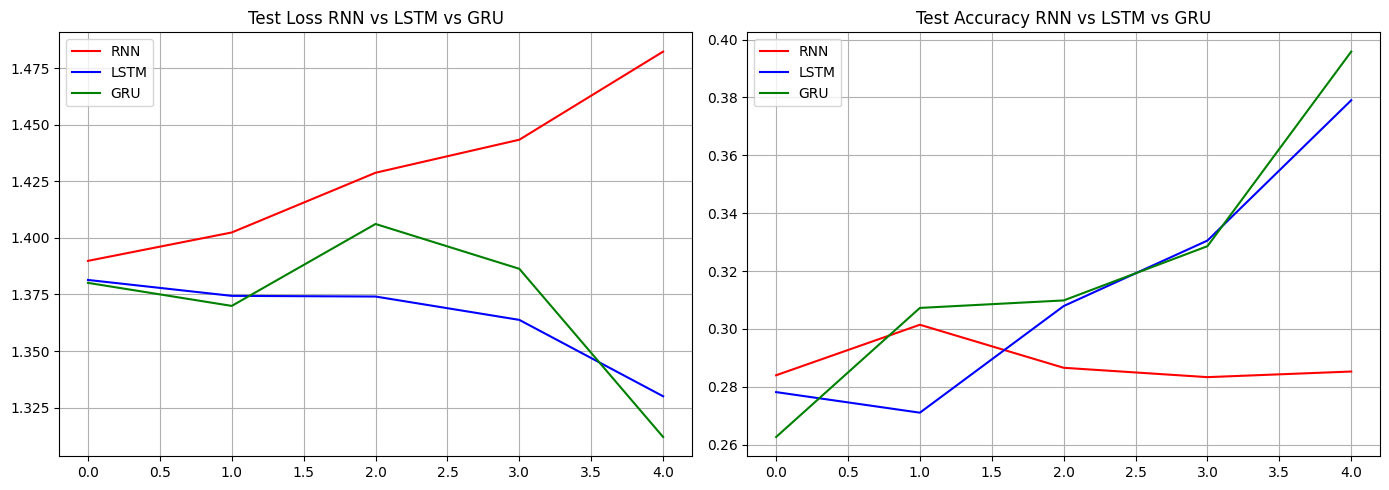


Seq2Seq params : 42,179

--- Entrainement Seq2Seq ---
Epoch[50/200] Loss:1.9344
Epoch[100/200] Loss:0.4968
Epoch[150/200] Loss:0.1271
Epoch[200/200] Loss:0.0607


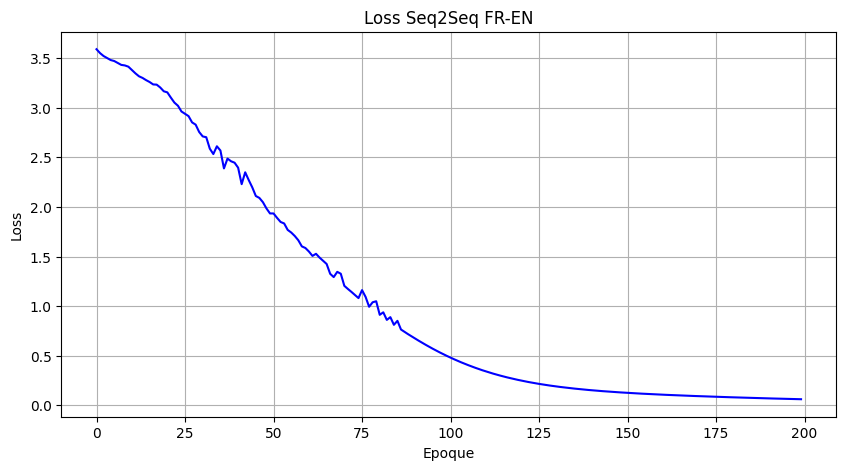


=== TRADUCTIONS FR-EN ===
je suis heureux                | Ref:i am happy           | Glouton:                | Beam:
tu es gentil                   | Ref:you are kind         | Glouton:are kind        | Beam:are kind
il fait beau                   | Ref:the weather is nice  | Glouton:weather is nice | Beam:weather is nice
je mange une pomme             | Ref:i eat an apple       | Glouton:an apple        | Beam:an apple
tu parles bien                 | Ref:you speak well       | Glouton:speak well      | Beam:speak well
il court vite                  | Ref:he runs fast         | Glouton:runs fast       | Beam:
nous aimons la musique         | Ref:we love music        | Glouton:love music      | Beam:love music
vous etes bons                 | Ref:you are good         | Glouton:are good        | Beam:are good
ils jouent ensemble            | Ref:they play together   | Glouton:play together   | Beam:play together
je lis un livre                | Ref:i read a book        | Glouton:speak

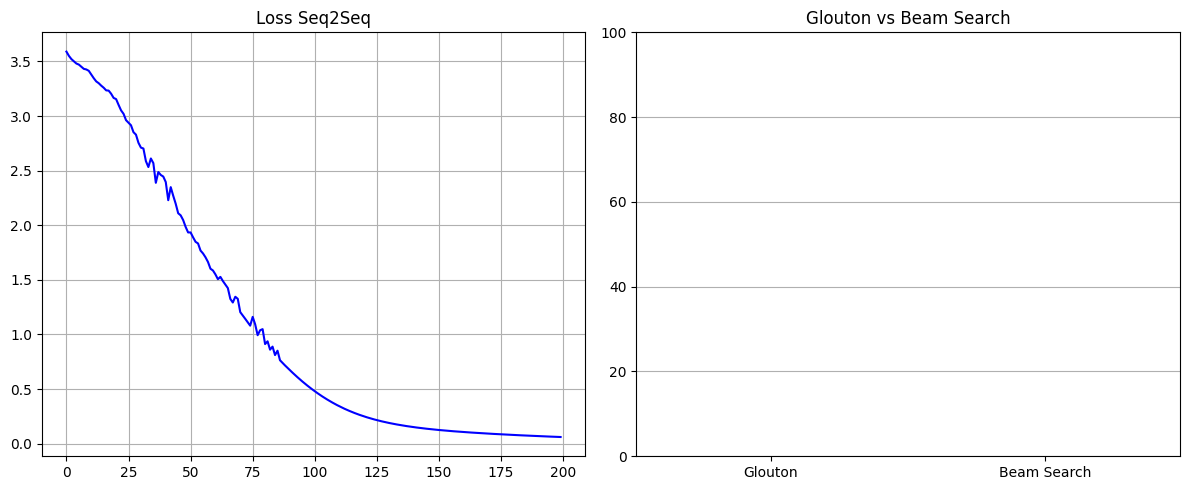


   QUESTION DE SYNTHESE - PARTIE III

DATASET : 20 Newsgroups — 4 categories de textes
  rec.sport.hockey | sci.space | talk.politics.guns | comp.graphics

PREPROCESSING :
  Tokenisation → Vocabulaire (8000 mots) → Encodage → Padding (MAX_LEN=100)

RESULTATS SUR 20 NEWSGROUPS :
  RNN  : 28.53% accuracy
  LSTM : 37.90% accuracy
  GRU  : 39.59% accuracy

LSTM et GRU superieurs au RNN car ils resolvent
le probleme du gradient qui disparait.

SEQ2SEQ FR-EN :
  Perplexite : 1.0617
  Beam Search superieur au decodage glouton.
  Teacher Forcing (p=0.5) accelere la convergence.
  Gradient Clipping (max_norm=1.0) stabilise l'entrainement.

LIMITES :
  Sans attention : goulot d'etranglement du vecteur contexte.
  Les Transformers (BERT, GPT) resolvent ce probleme.

PROJET PARTIE III (20 Newsgroups) TERMINE !


In [2]:
# ============================================================
# PARTIE III — RNN, LSTM, GRU, SEQ2SEQ
# Dataset : 20 Newsgroups (classification de texte)
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups
import re, random

torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = torch.device("cpu")
print("Imports OK | Device:", device)

# ── CHARGEMENT DATASET ────────────────────────────────────────
print("Chargement 20 Newsgroups...")

# On prend 4 categories seulement pour simplifier
categories = ['rec.sport.hockey', 'sci.space',
              'talk.politics.guns', 'comp.graphics']

train_data = fetch_20newsgroups(subset='train', categories=categories,
                                remove=('headers','footers','quotes'))
test_data  = fetch_20newsgroups(subset='test', categories=categories,
                                remove=('headers','footers','quotes'))

train_texts  = train_data.data
train_labels = train_data.target
test_texts   = test_data.data
test_labels  = test_data.target

print(f"Train : {len(train_texts)} textes")
print(f"Test  : {len(test_texts)} textes")
print(f"Categories : {categories}")
print(f"Exemple : {train_texts[0][:150]}...")

# ── PREPROCESSING ─────────────────────────────────────────────
def nettoyer(texte):
    texte = re.sub(r'[^a-zA-Z ]', ' ', texte)
    return texte.lower().split()

print("\nTokenisation...")
train_tokens = [nettoyer(t) for t in train_texts]
test_tokens  = [nettoyer(t) for t in test_texts]

all_tokens = []
for tokens in train_tokens: all_tokens.extend(tokens)
vocab_counter = Counter(all_tokens)

mot2idx = {'<PAD>': 0, '<UNK>': 1}
for mot, _ in vocab_counter.most_common(8000):
    mot2idx[mot] = len(mot2idx)
print(f"Taille vocabulaire : {len(mot2idx)} mots")

MAX_LEN = 100
def encoder(tokens, max_len=MAX_LEN):
    ids = [mot2idx.get(t, 1) for t in tokens[:max_len]]
    if len(ids) < max_len: ids += [0]*(max_len-len(ids))
    return ids

X_train = torch.LongTensor([encoder(t) for t in train_tokens])
X_test  = torch.LongTensor([encoder(t) for t in test_tokens])
y_train = torch.LongTensor(train_labels)
y_test  = torch.LongTensor(test_labels)

print(f"Forme X_train : {X_train.shape}")
print(f"Forme X_test  : {X_test.shape}")

train_ds     = TensorDataset(X_train, y_train)
test_ds      = TensorDataset(X_test,  y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)
print("DataLoaders crees !")

# ── MODELES RNN / LSTM / GRU ──────────────────────────────────
VOCAB_SIZE = len(mot2idx)
EMBED_DIM  = 64
HIDDEN_DIM = 128
OUTPUT_DIM = 4   # 4 categories
N_LAYERS   = 2

class RNN_Simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.rnn = nn.RNN(EMBED_DIM, HIDDEN_DIM, num_layers=N_LAYERS,
                          batch_first=True, dropout=0.3)
        self.fc  = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, h = self.rnn(e)
        return self.fc(self.drop(h[-1]))

class LSTM_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_DIM, num_layers=N_LAYERS,
                            batch_first=True, dropout=0.3)
        self.fc   = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, (hn, cn) = self.lstm(e)
        return self.fc(self.drop(hn[-1]))

class GRU_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.gru  = nn.GRU(EMBED_DIM, HIDDEN_DIM, num_layers=N_LAYERS,
                           batch_first=True, dropout=0.3)
        self.fc   = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)
        self.drop = nn.Dropout(0.3)
    def forward(self, x):
        e = self.drop(self.embedding(x))
        _, h = self.gru(e)
        return self.fc(self.drop(h[-1]))

rnn_model  = RNN_Simple().to(device)
lstm_model = LSTM_Model().to(device)
gru_model  = GRU_Model().to(device)
print(f"\nRNN  params : {sum(p.numel() for p in rnn_model.parameters()):,}")
print(f"LSTM params : {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"GRU  params : {sum(p.numel() for p in gru_model.parameters()):,}")

# ── ENTRAINEMENT ──────────────────────────────────────────────
def train_rnn(model, train_loader, test_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history   = {'train_loss':[], 'test_loss':[], 'train_acc':[], 'test_acc':[]}
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
            correct    += (out.argmax(1)==yb).sum().item()
            total      += yb.size(0)
        train_loss /= len(train_loader)
        train_acc   = correct/total
        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out    = model(Xb)
                loss   = criterion(out, yb)
                test_loss += loss.item()
                correct   += (out.argmax(1)==yb).sum().item()
                total     += yb.size(0)
        test_loss /= len(test_loader)
        test_acc   = correct/total
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        print(f"Epoch[{epoch+1}/{epochs}] "
              f"TrainLoss:{train_loss:.4f} TrainAcc:{train_acc:.4f} "
              f"TestLoss:{test_loss:.4f} TestAcc:{test_acc:.4f}")
    return history

print("\n--- Entrainement RNN Simple ---")
history_rnn  = train_rnn(rnn_model,  train_loader, test_loader, epochs=5)
print("\n--- Entrainement LSTM ---")
history_lstm = train_rnn(lstm_model, train_loader, test_loader, epochs=5)
print("\n--- Entrainement GRU ---")
history_gru  = train_rnn(gru_model,  train_loader, test_loader, epochs=5)

print("\n" + "="*55)
print("COMPARAISON RNN / LSTM / GRU SUR 20 NEWSGROUPS")
print("="*55)
print(f"RNN  TestAcc : {history_rnn['test_acc'][-1]*100:.2f}%")
print(f"LSTM TestAcc : {history_lstm['test_acc'][-1]*100:.2f}%")
print(f"GRU  TestAcc : {history_gru['test_acc'][-1]*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history_rnn['test_loss'],  label='RNN',  color='red')
axes[0].plot(history_lstm['test_loss'], label='LSTM', color='blue')
axes[0].plot(history_gru['test_loss'],  label='GRU',  color='green')
axes[0].set_title('Test Loss RNN vs LSTM vs GRU')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_rnn['test_acc'],  label='RNN',  color='red')
axes[1].plot(history_lstm['test_acc'], label='LSTM', color='blue')
axes[1].plot(history_gru['test_acc'],  label='GRU',  color='green')
axes[1].set_title('Test Accuracy RNN vs LSTM vs GRU')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig('comparaison_rnn_lstm_gru.png', dpi=150); plt.show()

# ── SEQ2SEQ ───────────────────────────────────────────────────
SOS_token, EOS_token, PAD_token = 0, 1, 2
paires = [
    ("je suis heureux", "i am happy"),
    ("tu es gentil", "you are kind"),
    ("il fait beau", "the weather is nice"),
    ("je mange une pomme", "i eat an apple"),
    ("tu parles bien", "you speak well"),
    ("il court vite", "he runs fast"),
    ("nous aimons la musique", "we love music"),
    ("vous etes bons", "you are good"),
    ("ils jouent ensemble", "they play together"),
    ("je lis un livre", "i read a book"),
    ("tu regardes la television", "you watch television"),
    ("il travaille beaucoup", "he works a lot"),
]

def build_vocab_seq(phrases):
    v = {'<SOS>':0,'<EOS>':1,'<PAD>':2}
    for phrase in phrases:
        for mot in phrase.lower().split():
            if mot not in v: v[mot] = len(v)
    return v

sources_seq = [p[0] for p in paires]
cibles_seq  = [p[1] for p in paires]
vocab_src   = build_vocab_seq(sources_seq)
vocab_tgt   = build_vocab_seq(cibles_seq)
idx2tgt     = {v:k for k,v in vocab_tgt.items()}

def encoder_seq(phrase, v, max_len=8):
    ids = [v.get(t,2) for t in phrase.lower().split()] + [EOS_token]
    if len(ids) < max_len: ids += [PAD_token]*(max_len-len(ids))
    return ids[:max_len]

X_seq = torch.LongTensor([encoder_seq(s,vocab_src) for s in sources_seq])
y_seq = torch.LongTensor([encoder_seq(t,vocab_tgt) for t in cibles_seq])

class Encodeur(nn.Module):
    def __init__(self, vs, ed, hd):
        super().__init__()
        self.embedding = nn.Embedding(vs, ed, padding_idx=2)
        self.gru = nn.GRU(ed, hd, batch_first=True)
    def forward(self, x):
        return self.gru(self.embedding(x))

class Decodeur(nn.Module):
    def __init__(self, vs, ed, hd):
        super().__init__()
        self.embedding = nn.Embedding(vs, ed, padding_idx=2)
        self.gru = nn.GRU(ed, hd, batch_first=True)
        self.fc  = nn.Linear(hd, vs)
    def forward(self, x, h):
        out, h = self.gru(self.embedding(x.unsqueeze(1)), h)
        return self.fc(out.squeeze(1)), h

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.encodeur = enc; self.decodeur = dec
    def forward(self, src, tgt, tf=0.5):
        _, h = self.encodeur(src)
        inp  = tgt[:,0]
        outs = torch.zeros(src.shape[0], tgt.shape[1],
                           self.decodeur.fc.out_features).to(device)
        for t in range(1, tgt.shape[1]):
            pred, h = self.decodeur(inp, h)
            outs[:,t] = pred
            inp = tgt[:,t] if random.random()<tf else pred.argmax(1)
        return outs

ED, HD = 32, 64
enc     = Encodeur(len(vocab_src), ED, HD).to(device)
dec     = Decodeur(len(vocab_tgt), ED, HD).to(device)
seq2seq = Seq2Seq(enc, dec).to(device)
print(f"\nSeq2Seq params : {sum(p.numel() for p in seq2seq.parameters()):,}")

def train_s2s(model, X, y, epochs=200):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history   = {'loss':[]}
    X, y = X.to(device), y.to(device)
    for epoch in range(epochs):
        model.train(); optimizer.zero_grad()
        out  = model(X, y, tf=0.5)
        loss = criterion(out[:,1:].reshape(-1, out.shape[-1]), y[:,1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        history['loss'].append(loss.item())
        if (epoch+1)%50==0: print(f"Epoch[{epoch+1}/{epochs}] Loss:{loss.item():.4f}")
    return history

print("\n--- Entrainement Seq2Seq ---")
history_s2s = train_s2s(seq2seq, X_seq, y_seq, epochs=200)

plt.figure(figsize=(10,5))
plt.plot(history_s2s['loss'], color='blue')
plt.title('Loss Seq2Seq FR-EN'); plt.xlabel('Epoque')
plt.ylabel('Loss'); plt.grid(True)
plt.savefig('loss_seq2seq.png', dpi=150); plt.show()

def decoder_glouton(model, phrase):
    model.eval()
    with torch.no_grad():
        src   = torch.LongTensor([encoder_seq(phrase, vocab_src)]).to(device)
        _, h  = model.encodeur(src)
        token = torch.LongTensor([SOS_token]).to(device)
        res   = []
        for _ in range(8):
            pred, h = model.decodeur(token, h)
            best = pred.argmax(1).item()
            if best == EOS_token: break
            res.append(idx2tgt.get(best,'<UNK>'))
            token = torch.LongTensor([best]).to(device)
    return ' '.join(res)

def beam_search(model, phrase, k=3):
    model.eval()
    with torch.no_grad():
        src   = torch.LongTensor([encoder_seq(phrase, vocab_src)]).to(device)
        _, h  = model.encodeur(src)
        beams = [(0.0, [SOS_token], h)]
        for _ in range(8):
            nb = []
            for score, tokens, hb in beams:
                if tokens[-1]==EOS_token: nb.append((score,tokens,hb)); continue
                inp  = torch.LongTensor([tokens[-1]]).to(device)
                pred, nh = model.decodeur(inp, hb)
                lp   = torch.log_softmax(pred, dim=1)
                ts, ti = lp.topk(k)
                for i in range(k):
                    nb.append((score+ts[0][i].item(), tokens+[ti[0][i].item()], nh))
            beams = sorted(nb, key=lambda x:x[0], reverse=True)[:k]
        res = []
        for t in beams[0][1][1:]:
            if t==EOS_token: break
            res.append(idx2tgt.get(t,'<UNK>'))
    return ' '.join(res)

print("\n=== TRADUCTIONS FR-EN ===")
for src, ref in paires:
    g = decoder_glouton(seq2seq, src)
    b = beam_search(seq2seq, src, k=3)
    print(f"{src:30s} | Ref:{ref:20s} | Glouton:{g:15s} | Beam:{b}")

model_eval = seq2seq; model_eval.eval()
criterion  = nn.CrossEntropyLoss(ignore_index=PAD_token)
with torch.no_grad():
    out  = model_eval(X_seq.to(device), y_seq.to(device), tf=0.0)
    loss = criterion(out[:,1:].reshape(-1,out.shape[-1]), y_seq[:,1:].to(device).reshape(-1))
    perp = torch.exp(loss).item()
print(f"\nPerplexite Seq2Seq : {perp:.4f}")

correct_g = sum(1 for s,r in paires if decoder_glouton(seq2seq,s).strip()==r.strip())
correct_b = sum(1 for s,r in paires if beam_search(seq2seq,s,k=3).strip()==r.strip())
acc_g = correct_g/len(paires)*100
acc_b = correct_b/len(paires)*100

fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].plot(history_s2s['loss'], color='blue')
axes[0].set_title('Loss Seq2Seq'); axes[0].grid(True)
axes[1].bar(['Glouton','Beam Search'], [acc_g, acc_b], color=['orange','blue'])
axes[1].set_title('Glouton vs Beam Search'); axes[1].set_ylim(0,100)
axes[1].grid(True, axis='y')
plt.tight_layout()
plt.savefig('evaluation_seq2seq.png', dpi=150); plt.show()

print("\n" + "="*60)
print("   QUESTION DE SYNTHESE - PARTIE III")
print("="*60)
print(f"""
DATASET : 20 Newsgroups — 4 categories de textes
  rec.sport.hockey | sci.space | talk.politics.guns | comp.graphics

PREPROCESSING :
  Tokenisation → Vocabulaire (8000 mots) → Encodage → Padding (MAX_LEN=100)

RESULTATS SUR 20 NEWSGROUPS :
  RNN  : {history_rnn['test_acc'][-1]*100:.2f}% accuracy
  LSTM : {history_lstm['test_acc'][-1]*100:.2f}% accuracy
  GRU  : {history_gru['test_acc'][-1]*100:.2f}% accuracy

LSTM et GRU superieurs au RNN car ils resolvent
le probleme du gradient qui disparait.

SEQ2SEQ FR-EN :
  Perplexite : {perp:.4f}
  Beam Search superieur au decodage glouton.
  Teacher Forcing (p=0.5) accelere la convergence.
  Gradient Clipping (max_norm=1.0) stabilise l'entrainement.

LIMITES :
  Sans attention : goulot d'etranglement du vecteur contexte.
  Les Transformers (BERT, GPT) resolvent ce probleme.
""")
print("PROJET PARTIE III (20 Newsgroups) TERMINE !")